In [180]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
%reload_ext autoreload

import json
from easydict import EasyDict
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from dataset.ZOD import ZOD  # adjust import path

In [182]:

# --- Load config ---
cfg_path = "models/config/ZOD/train.json"
with open(cfg_path, "r") as f:
    cfg = EasyDict(json.load(f))

# Hard-code or add to cfg: roots + version
cfg.lidar_dataset_root = "/work/vita/datasets/zod"
cfg.aerial_img_dataset_root = "/work/vita/datasets/zod_crossview_processed_100m"
cfg.version = "full"

# Build small ZOD config used by the class
zod_cfg = {
    "lidar_dataset_root": cfg.lidar_dataset_root,
    "aerial_img_dataset_root": cfg.aerial_img_dataset_root,
    "version": cfg.version,
    "point_limit": getattr(cfg, "point_limit", None),
    "use_augmentation": cfg.use_augmentation,
    "augmentation_noise": getattr(cfg, "augmentation_noise", 0.0),
    "augmentation_rotation": getattr(cfg, "augmentation_rotation", 0.0),
    "image_size": cfg.image_size,
    "image_area_dg_m": cfg.image_area_dg_m,
    "image_area_zod_m": cfg.image_area_zod_m,
    "max_translation": cfg.max_translation,
    "max_rot_deg": cfg.max_rot_deg,
    "z_range": cfg.z_range,
    "BEV_grid_resolution": cfg.BEV_grid_resolution,
}

dataset = ZOD(task="train", **zod_cfg)
print("Dataset length:", len(dataset))


Loading infos: 0it [00:00, ?it/s]

Loading train split : 23 drives


Processing ZOD Drives:   4%|▍         | 202/4869 [00:05<02:05, 37.20Frame/s]


Dataset length: 202


In [183]:
data = dataset[0]

In [184]:
data

{'image_rgb_init': array([[[131., 129., 132.],
         [131., 129., 132.],
         [131., 129., 132.],
         ...,
         [159., 163., 164.],
         [160., 164., 165.],
         [160., 164., 165.]],
 
        [[131., 129., 132.],
         [131., 129., 132.],
         [131., 129., 132.],
         ...,
         [159., 163., 164.],
         [160., 164., 165.],
         [160., 164., 165.]],
 
        [[130., 128., 131.],
         [130., 128., 131.],
         [130., 128., 131.],
         ...,
         [160., 164., 165.],
         [155., 159., 160.],
         [155., 159., 160.]],
 
        ...,
 
        [[157.,  91.,  95.],
         [157.,  91.,  95.],
         [157.,  91.,  95.],
         ...,
         [ 59.,  40.,  46.],
         [ 64.,  45.,  49.],
         [ 64.,  45.,  49.]],
 
        [[157.,  91.,  95.],
         [157.,  91.,  95.],
         [157.,  91.,  95.],
         ...,
         [ 59.,  40.,  46.],
         [ 64.,  45.,  49.],
         [ 64.,  45.,  49.]],
 
        [[15

In [185]:
data["image"].shape

(3, 512, 512)

In [186]:
points_xyz = data["points"]
points_r = data["intensity"]

x_range=(-25.0, 25.0)
y_range=x_range
z_range=[-2.5, 3.0]
grid_res=0.1

x_min, x_max = x_range
y_min, y_max = y_range
z_min, z_max = z_range

# Filter ROI
x = points_xyz[:, 0]
y = points_xyz[:, 1]
z = points_xyz[:, 2]
r = (points_r.astype(np.float32) / 255.0) # normalize for more usable range for the model


In [187]:
temp_i = np.abs(x).argmin()
y[temp_i], z[temp_i]

(-2.7451673, 11.8848915)

In [200]:

mask = (x > x_min) & (x < x_max) & \
    (y > y_min) & (y < y_max) & \
    (z > z_min) & (z < z_max)
if not np.any(mask):
    print("Mask empty")

x = x[mask]; y = y[mask]; z = z[mask]; r = r[mask]

X_SIZE = int((x_max - x_min) / grid_res)
Y_SIZE = int((y_max - y_min) / grid_res)
Z_SIZE = int((z_max - z_min) / grid_res)

# Quantize
X = ((x - x_min) / grid_res).astype(np.int32)
Y = ((y - y_min) / grid_res).astype(np.int32)
Z = ((z - z_min) / grid_res).astype(np.int32)

# Safety clip
X = np.clip(X, 0, X_SIZE - 1)
Y = np.clip(Y, 0, Y_SIZE - 1)
Z = np.clip(Z, 0, Z_SIZE - 1)

# Allocate: (Y, X, Z+1)
bev = np.zeros((Y_SIZE, X_SIZE, Z_SIZE + 1), dtype=np.float32)
density = np.zeros((Y_SIZE, X_SIZE), dtype=np.int32)

# Fill occupancy + accumulated intensity
for i in range(X.shape[0]):
    yy, xx, zz = Y[i], X[i], Z[i]
    bev[yy, xx, zz] = 1.0
    bev[yy, xx, Z_SIZE] += r[i]
    density[yy, xx] += 1

# Normalize intensity channel
mask_den = density > 0
bev[mask_den, Z_SIZE] /= density[mask_den]

# (C,H,W) for PyTorch
bev = bev.transpose(2, 0, 1)  # (Z+1, Y, X)

In [198]:
points_xyz.shape

(280800, 3)

In [199]:
data = dataset[100]
points_xyz = data["points"]
points_r = data["intensity"]

x_range=(-25.0, 25.0)
y_range=x_range
z_range=[-2.5, 3.0]
grid_res=0.1

x_min, x_max = x_range
y_min, y_max = y_range
z_min, z_max = z_range

# Filter ROI
x = points_xyz[:, 0]
y = points_xyz[:, 1]
z = points_xyz[:, 2]
r = (points_r.astype(np.float32) / 255.0) # normalize for more usable range for the model


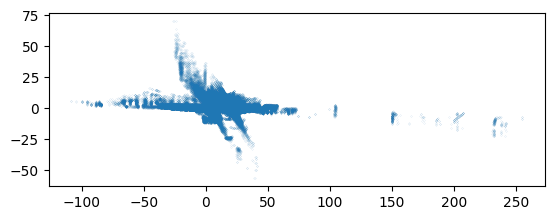

In [191]:
plt.plot(x,z,".", markersize=0.1)
# make square
plt.gca().set_aspect('equal')

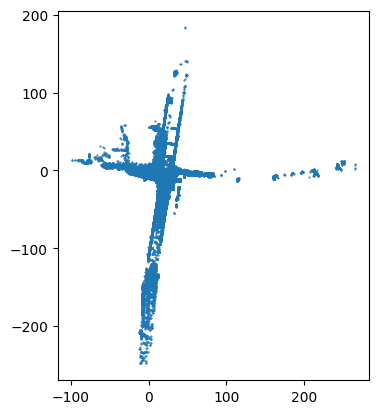

In [192]:
lid_points = np.array([x,y,z]).T
lid_points_rot = lid_points @ data["rotation"].T + data["translation"]
plt.plot(lid_points_rot[:,0],lid_points_rot[:,1],".", markersize=1)
plt.gca().set_aspect('equal')

In [193]:
lid_points.shape

(280800, 3)

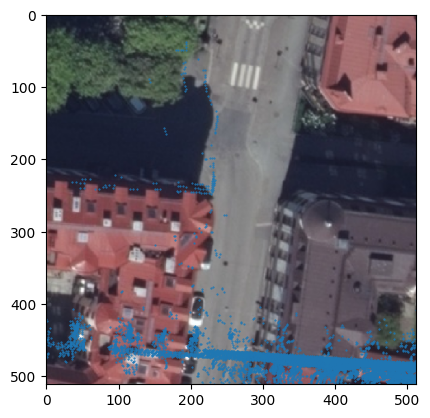

In [194]:
im = np.transpose(data["image"], [1,2,0])

lid_points_rot = (data["points"] @ data["rotation"].T + data["translation"])/(data["resolution"])
x = im.shape[0] + lid_points_rot[:,0]
y = im.shape[1] - lid_points_rot[:,1]

plt.plot(x,y,".", markersize=1)
plt.imshow(im, origin = "upper")

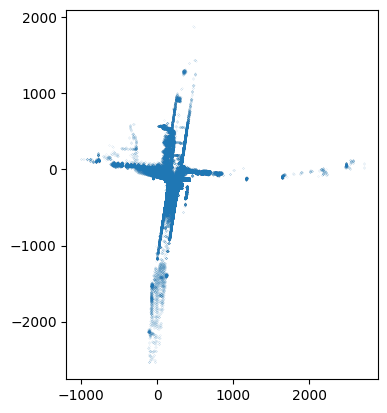

In [195]:
lid_points_rot = (data["points"] @ data["rotation"].T + data["translation"])/data["resolution"]
plt.plot(lid_points_rot[:,0],lid_points_rot[:,1],".", markersize=0.1)
plt.gca().set_aspect('equal')

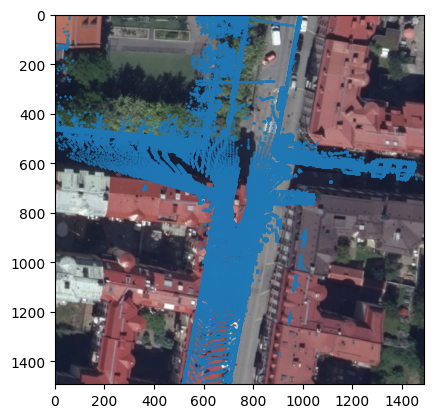

In [204]:
im = data["image_rgb_init"]

s = (100/1492)

lid_points_rot = ((data["points"] - data["translation"]) @ np.linalg.inv(data["rotation"].T) )/s

x = lid_points_rot[:,0]
y = lid_points_rot[:,1]
# mask = (x > x_min/s) & (x < x_max/s) & (y > y_min/s) & (y < y_max/s) 
# if not np.any(mask):
#     print("Mask empty")
# x = x[mask]
# y = y[mask]
x = im.shape[0]//2 + x
y = im.shape[1]//2 - y

plt.plot(x,y,".", markersize=1)
plt.imshow(im.astype(int), origin="upper")

In [208]:

data = dataset[300]

im = np.transpose(data["image"], [1,2,0])


s = 50/im.shape[0] #(100/1492)
lid_points_rot = ((data["points"] - data["translation"]) @ np.linalg.inv(data["rotation"].T) )/s
x = lid_points_rot[:,0]
y = lid_points_rot[:,1]
mask = (x > x_min/s) & (x < x_max/s) & (y > y_min/s) & (y < y_max/s) 
if not np.any(mask):
    print("Mask empty")
x = x[mask]
y = y[mask]
x = im.shape[0]//2 + x
y = im.shape[1]//2 - y

plt.plot(x,y,".", markersize=0.5)
plt.gca().set_aspect('equal')



plt.imshow(im, origin = "upper")

IndexError: list index out of range

In [ ]:
im.shape[0], x_max/s

(1492, 373.0)

In [201]:
np.sum(mask == 1)

157361

In [ ]:
mask == 1

array([ True, False, False, ..., False, False,  True])

In [ ]:
mask.shape, x.shape

((292054,), (140202,))

In [207]:
from tqdm import tqdm
pbar = tqdm(total=len(dataset), desc="Processing ZOD Drives", unit="Frame", colour="blue")

for i, dat in enumerate(dataset):
    if "bev_lidar" not in dat.keys():
        print("BEV failed at iteration", i, dat["scene_name"], dat["name"])
    pbar.update(1)

Processing ZOD Drives:  64%|██████▍   | 129/202 [04:03<02:01,  1.66s/Frame]

KeyboardInterrupt: 

In [209]:
data["bev_lidar"]

array([[[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0. 

In [35]:
pth_path = "metrics/feature_visualization/features.pth"

# open file and plot the image and lidar features to see if they look reasonable
import torch
import matplotlib.pyplot as plt


/tmp/ipykernel_1995318/1503362448.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(pth_path)


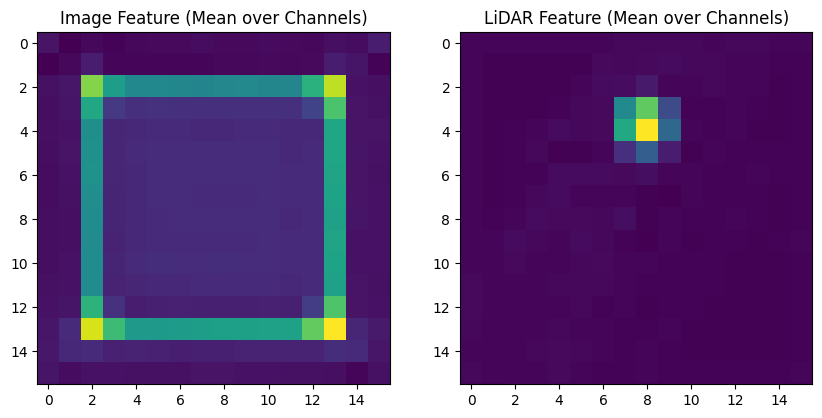

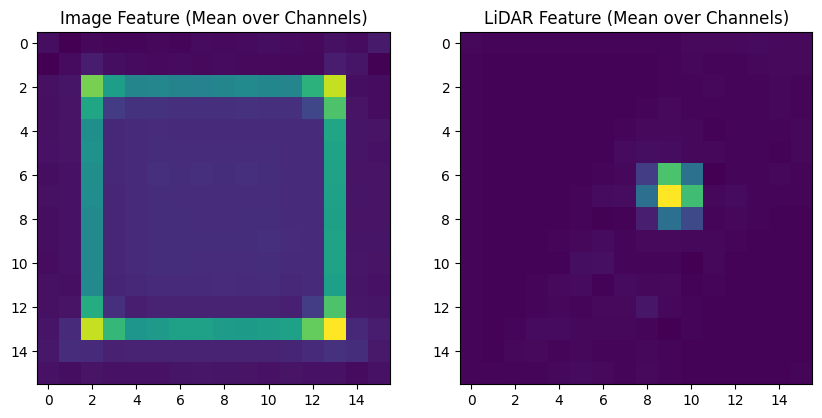

In [36]:
data = torch.load(pth_path)
for i in range(len(data["entries"])):
    entry = data["entries"][i]
    img_feat = entry["image_feature"]
    lidar_feat = entry["lidar_feature"]
    
    # print(img_feat.shape, lidar_feat.shape)
    # respectively torch.Size([1, 320, 16, 16]) torch.Size([1, 320, 16, 16])
    
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(img_feat.squeeze().numpy()[0,:,:], cmap='viridis')
    axs[0].set_title('Image Feature (Mean over Channels)')
    axs[1].imshow(lidar_feat.squeeze().numpy()[0,:,:], cmap='viridis')
    axs[1].set_title('LiDAR Feature (Mean over Channels)')
    plt.show()

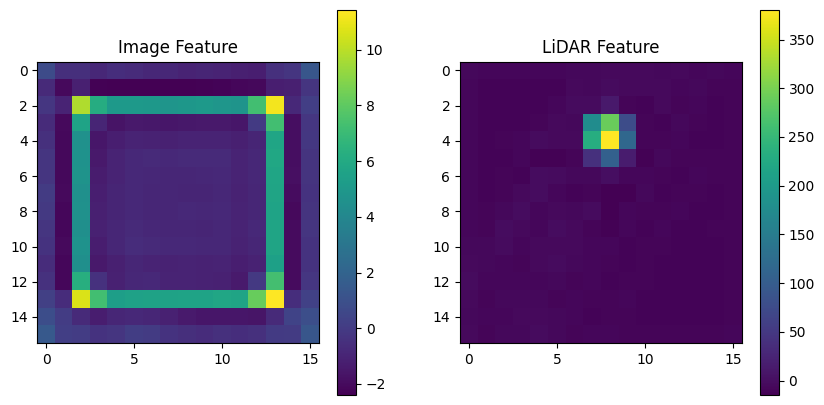

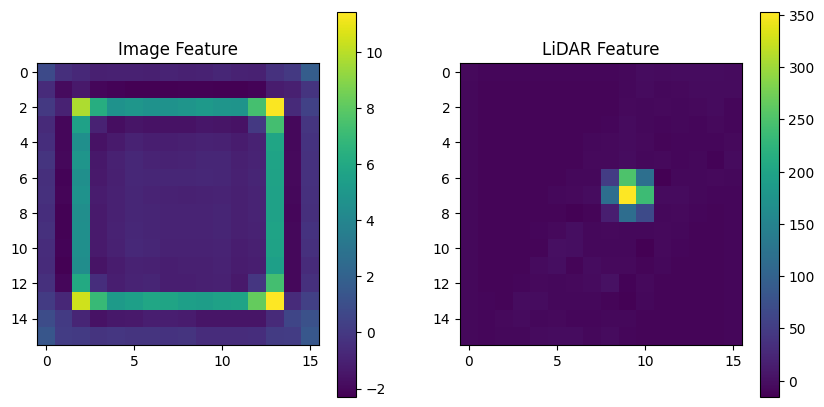

In [37]:
for i in range(len(data["entries"])):
    entry = data["entries"][i]
    img_feat = entry["image_feature"]
    lidar_feat = entry["lidar_feature"]
    
    # print(img_feat.shape, lidar_feat.shape)
    # respectively torch.Size([1, 320, 16, 16]) torch.Size([1, 320, 16, 16])
    
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(img_feat.squeeze().numpy()[100,:,:], cmap='viridis')
    axs[0].set_title('Image Feature')
    axs[1].imshow(lidar_feat.squeeze().numpy()[100,:,:], cmap='viridis')
    axs[1].set_title('LiDAR Feature')
    
    
    # add colorbars
    fig.colorbar(axs[0].images[0], ax=axs[0])
    fig.colorbar(axs[1].images[0], ax=axs[1])
    plt.show()

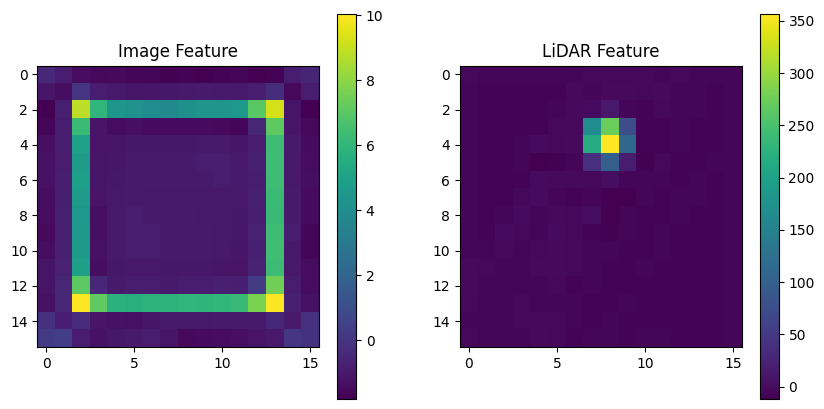

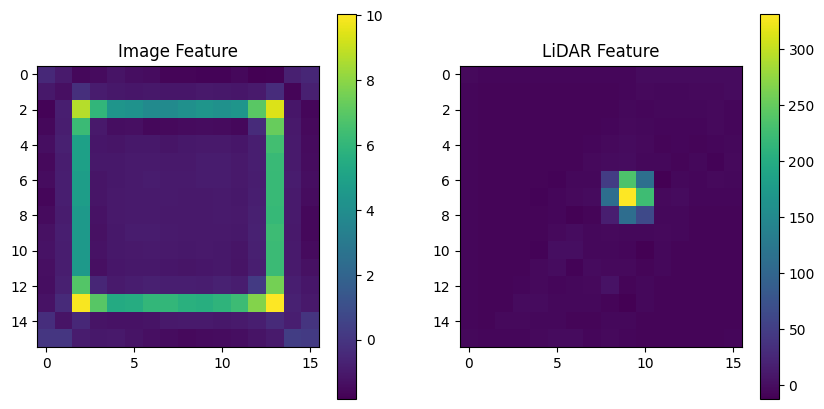

In [38]:
for i in range(len(data["entries"])):
    entry = data["entries"][i]
    img_feat = entry["image_feature"]
    lidar_feat = entry["lidar_feature"]
    
    # print(img_feat.shape, lidar_feat.shape)
    # respectively torch.Size([1, 320, 16, 16]) torch.Size([1, 320, 16, 16])
    
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(img_feat.squeeze().numpy()[-1,:,:], cmap='viridis')
    axs[0].set_title('Image Feature')
    axs[1].imshow(lidar_feat.squeeze().numpy()[-1,:,:], cmap='viridis')
    axs[1].set_title('LiDAR Feature')
    
    # add colorbars
    fig.colorbar(axs[0].images[0], ax=axs[0])
    fig.colorbar(axs[1].images[0], ax=axs[1])
    plt.show()

torch.Size([256, 16, 16]) torch.Size([256, 1, 8, 8])


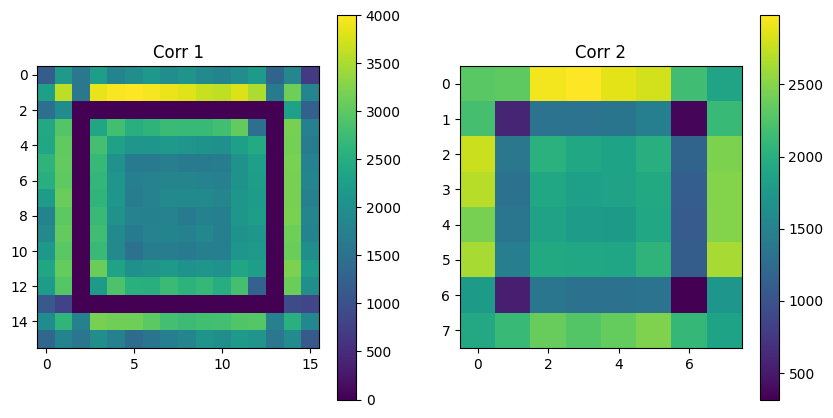

torch.Size([256, 16, 16]) torch.Size([256, 1, 8, 8])


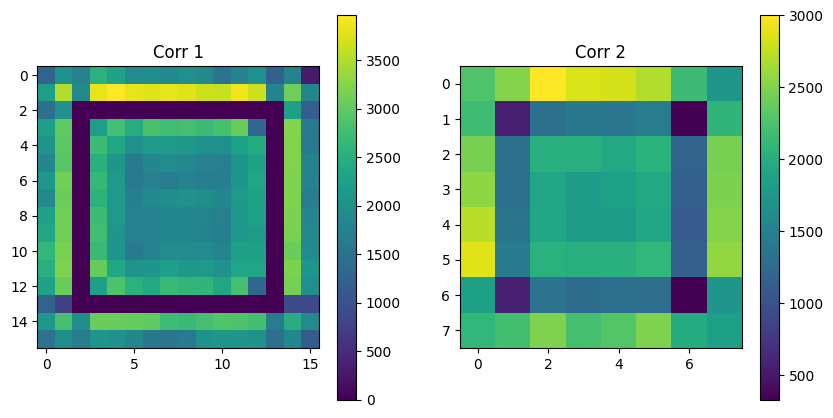

In [42]:
for i in range(len(data["entries"])):
    entry = data["entries"][i]
    corr1 = entry["correlation"][0]
    corr2 = entry["correlation"][1]
    print(corr1.squeeze().shape, corr2.shape)
    # respectively torch.Size([1, 320, 16, 16]) torch.Size([1, 320, 16, 16])
    
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(corr1.squeeze().numpy()[1,:,:], cmap='viridis')
    axs[0].set_title('Corr 1')
    axs[1].imshow(corr2.squeeze().numpy()[1,:,:], cmap='viridis')
    axs[1].set_title('Corr 2')
    
    # add colorbars
    fig.colorbar(axs[0].images[0], ax=axs[0])
    fig.colorbar(axs[1].images[0], ax=axs[1])
    plt.show()